1D final x ~ 2, f(x)=3.949e-19


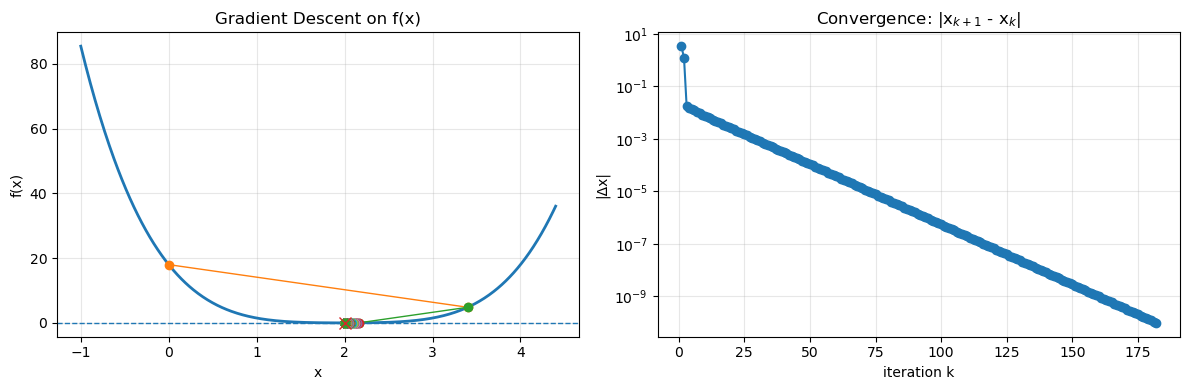

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Core Gradient Descent
# ------------------------------
def gradient_descent(grad, x0, lr=0.1, maxiter=500, tol=1e-8,
                     line_search=False, c=1e-4, beta=0.5, f=None):
    """
    Gradient Descent for 1D or nD.

    Parameters
    ----------
    grad : callable
        Gradient function: grad(x) -> same shape as x.
    x0 : float or np.ndarray
        Initial guess.
    lr : float
        Learning rate (ignored if line_search=True).
    maxiter : int
        Maximum iterations.
    tol : float
        Stop when ||x_{k+1}-x_k|| < tol or ||grad(x_k)|| < tol.
    line_search : bool
        If True, use Armijo backtracking (requires f).
    c, beta : float
        Armijo parameters: f(x - t*g) <= f(x) - c*t*||g||^2 with t *= beta.

    Returns
    -------
    xs : list of np.ndarray
        Iterates.
    """
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    for _ in range(maxiter):
        g = np.array(grad(x))
        gnorm = np.linalg.norm(g)
        if gnorm < tol:
            break

        t = lr
        if line_search:
            if f is None:
                raise ValueError("line_search=True requires f.")
            fx = f(x)
            # Armijo backtracking
            while True:
                xn = x - t * g
                if f(xn) <= fx - c * t * (gnorm**2):
                    break
                t *= beta
                if t < 1e-16:
                    # step collapsed; bail out
                    break
        xn = x - t * g
        xs.append(xn.copy())
        if np.linalg.norm(xn - x) < tol:
            x = xn
            break
        x = xn
    return xs

# ------------------------------
# 1D Visualization
# ------------------------------
def plot_gd_1d(f, grad, xs, x_range=None, npts=600):
    if np.ndim(xs[0]) != 0:
        raise ValueError("plot_gd_1d expects scalar x (1D problem).")

    if x_range is None:
        xmin = min(xs) - 1.0
        xmax = max(xs) + 1.0
    else:
        xmin, xmax = x_range

    X = np.linspace(xmin, xmax, npts)
    Y = f(X)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax_f, ax_conv = axes

    # Left: f(x) and iterates
    ax_f.plot(X, Y, lw=2)
    ax_f.axhline(0, ls='--', lw=1)
    ax_f.set_title("Gradient Descent on f(x)")
    ax_f.set_xlabel("x"); ax_f.set_ylabel("f(x)")
    ax_f.grid(True, alpha=0.3)

    # Path on f(x)
    for k in range(len(xs)-1):
        xk, xk1 = xs[k], xs[k+1]
        ax_f.plot([xk, xk1], [f(xk), f(xk1)], marker='o', lw=1)
    ax_f.plot([xs[-1]], [f(xs[-1])], marker='x', ms=8)

    # Right: convergence: |x_{k+1} - x_k|
    if len(xs) > 1:
        steps = np.abs(np.diff(xs))
        ax_conv.semilogy(range(1, len(xs)), steps, marker='o')
        ax_conv.set_title("Convergence: |x$_{k+1}$ - x$_k$|")
        ax_conv.set_xlabel("iteration k"); ax_conv.set_ylabel("|Δx|")
        ax_conv.grid(True, which='both', alpha=0.3)
    else:
        ax_conv.text(0.5, 0.5, "No iteration performed", ha='center', va='center')
        ax_conv.axis('off')

    plt.tight_layout()
    plt.show()

# ------------------------------
# 2D Visualization (contours + path)
# ------------------------------
def plot_gd_2d(f, xs, x_range=None, npts=200, levels=40):
    xs_arr = np.array(xs)
    if xs_arr.ndim != 2 or xs_arr.shape[1] != 2:
        raise ValueError("plot_gd_2d expects 2D iterates with shape (k, 2).")

    if x_range is None:
        xmin, xmax = xs_arr[:,0].min()-0.5, xs_arr[:,0].max()+0.5
        ymin, ymax = xs_arr[:,1].min()-0.5, xs_arr[:,1].max()+0.5
    else:
        (xmin, xmax), (ymin, ymax) = x_range

    X = np.linspace(xmin, xmax, npts)
    Y = np.linspace(ymin, ymax, npts)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.zeros_like(XX)
    for i in range(npts):
        for j in range(npts):
            ZZ[i, j] = f(np.array([XX[i, j], YY[i, j]]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax_c, ax_conv = axes

    # Left: contour + path
    cs = ax_c.contour(XX, YY, ZZ, levels=levels)
    ax_c.clabel(cs, inline=True, fontsize=8)
    ax_c.plot(xs_arr[:,0], xs_arr[:,1], marker='o', lw=1.5)
    ax_c.set_title("Gradient Descent Path (2D)")
    ax_c.set_xlabel("x"); ax_c.set_ylabel("y")
    ax_c.grid(True, alpha=0.2)

    # Right: convergence of step norm
    steps = np.linalg.norm(np.diff(xs_arr, axis=0), axis=1) if len(xs_arr) > 1 else []
    if len(steps) > 0:
        ax_conv.semilogy(range(1, len(xs_arr)), steps, marker='o')
        ax_conv.set_title("Convergence: ||x$_{k+1}$ - x$_k$||")
        ax_conv.set_xlabel("iteration k"); ax_conv.set_ylabel("||Δx||")
        ax_conv.grid(True, which='both', alpha=0.3)
    else:
        ax_conv.text(0.5, 0.5, "No iteration performed", ha='center', va='center')
        ax_conv.axis('off')

    plt.tight_layout()
    plt.show()

# ------------------------------
# Examples
# ------------------------------
if __name__ == "__main__":
    # ===== 1) 1D example =====
    # Smooth, strongly convex quartic+quadratic near x=2
    def f1(x):  return (x-2.0)**4 + 0.5*(x-2.0)**2
    def g1(x):  return 4*(x-2.0)**3 + (x-2.0)

    x0_1d = 0.0
    xs_1d = gradient_descent(g1, x0_1d, lr=0.1, maxiter=200, tol=1e-10,
                             line_search=False)  # try True with f=f1
    print(f"1D final x ~ {xs_1d[-1]:.6g}, f(x)={f1(xs_1d[-1]):.3e}")
    plot_gd_1d(f1, g1, xs_1d, x_range=(min(xs_1d)-1, max(xs_1d)+1))

    # ===== 2) 2D example (Rosenbrock) =====
    # f(x,y) = (1-x)^2 + 100(y - x^2)^2
    def f2(v):
        x, y = v
        return (1-x)**2 + 100.0*(y - x**2)**2

    def g2(v):
        x, y = v
        dfdx = -2*(1-x) - 400*x*(y - x**2)
        dfdy = 200*(y - x**2)
        return np.array([dfdx, dfdy])

    x0_2d = np.array([-1.2, 1.0])
    xs_2d = gradient_descent(g2, x0_2d, lr=1e-3, maxiter=20000, tol=1e-8,
                             line_search=True, f=f2)  # line searc_
